# RL Group Project:  Q-Learning and Expected Sarsa on GridWorld (Fox2016) – Model-Based Transitions

In this notebook you will:

1. Implement Q‑Learning with ε‑greedy action selection.
2. Implement Expected Sarsa with ε‑greedy action selection.
3. Compare their performance on the 8×8 GridWorld environment described in Fox (2016), using precomputed transition probabilities and costs.

**Environment details**:
- States: 64 flat indices (0…63). Terminal state is index 36 `[4,4]`.
- Blocked (invalid) states: 15 indices listed in `inv_st`.
- Actions: 9 moves (0…8).
- Transition and cost matrices `P` and `C` are precomputed.
- Episodes start at a random non‑blocked, non‑terminal state.
- Episode ends when state 36 is reached.
- Cost is accumulated as defined in `C`.

Imports

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import sem

In [5]:
# =============================================================================
# State/Action indexing
# =============================================================================
N1 = 8
S_size = 64

states = {}
states_pr = {}
k = 0
for i in range(N1):
    for j in range(N1):
        states[k] = (i, j)
        states_pr[(i, j)] = k
        k += 1

# Action deltas
actions = {
    0: (-1,  0), 1: (-1,  1), 2: ( 0,  1), 3: ( 1,  1),
    4: ( 1,  0), 5: ( 1, -1), 6: ( 0, -1), 7: (-1, -1),
    8: ( 0,  0)
}

S = np.arange(64)
A = np.arange(9)
P = np.zeros((64, 64, 9))   # P[next_state, current_state, action]
C = np.zeros((64, 64, 9))

inv_st = np.array([9, 17, 25, 33, 34, 42, 50, 12, 20, 28, 29, 30, 38, 46, 54])

# =============================================================================
# Build transition model P and cost model C (as provided)
# =============================================================================
for a in range(9):
    for s in range(64):
        if s in inv_st:
            continue
        s_0, s_1 = states[s]
        if s == 36:          # terminal state
            P[s, s, a] = 1
            C[s, s, a] = 0
            continue

        s_pr_0 = s_0 + actions[a][0]
        s_pr_1 = s_1 + actions[a][1]

        if a == 8:
            s_pr_0, s_pr_1, s_pr = s_0, s_1, s
            C[s_pr, s, a] = 1
        elif s_pr_0 < 0 or s_pr_0 > 7 or s_pr_1 < 0 or s_pr_1 > 7:
            s_pr_0, s_pr_1, s_pr = s_0, s_1, s
        else:
            s_pr = states_pr[(s_pr_0, s_pr_1)]
            if s_pr == 36:
                P[s_pr, s, a] = 1
                C[s_pr, s, a] = 1
                continue
            if s_pr in inv_st:
                s_pr_0, s_pr_1, s_pr = s_0, s_1, s

        s_pr_0_old, s_pr_1_old, s_pr_old = s_pr_0, s_pr_1, s_pr
        p = 0

        for i in range(8):
            s_pr_0 = s_pr_0_old + actions[i][0]
            s_pr_1 = s_pr_1_old + actions[i][1]
            if 0 <= s_pr_0 <= 7 and 0 <= s_pr_1 <= 7:
                s_pr = states_pr[(s_pr_0, s_pr_1)]
                if s_pr in inv_st:
                    P[s_pr, s, a] = 0
                else:
                    if abs(actions[i][0]) + abs(actions[i][1]) == 1:
                        P[s_pr, s, a] = 0.05
                        p += 0.05
                        C[s_pr, s, a] = 2 if s_pr_old != s else 1
                    else:
                        P[s_pr, s, a] = 0.025
                        p += 0.025
                        C[s_pr, s, a] = 2 if s_pr_old != s else 1

        P[s_pr_old, s, a] += 1 - p
        C[s_pr_old, s, a] = 1

print("Transition and cost matrices built.")

Transition and cost matrices built.


#### Environment Class Using P and C

In [6]:
class GridWorldEnv:
    def __init__(self, P, C, inv_st):
        self.P = P          # shape (64,64,9)
        self.C = C          # shape (64,64,9)
        self.inv_st = inv_st
        self.state = None
        self.rng = np.random.default_rng()

    def reset(self):
        """Random start state (non-blocked, non-terminal)."""
        while True:
            s = self.rng.integers(64)
            if s not in self.inv_st and s != 36:
                self.state = s
                return s

    def step(self, action):
        """Returns: next_state, cost, done, info."""
        s = self.state
        if s == 36:
            return 36, 0.0, True, {}

        # Sample next state from transition probabilities
        probs = self.P[:, s, action]   # shape (64,)
        next_state = self.rng.choice(64, p=probs)
        cost = self.C[next_state, s, action]

        done = (next_state == 36)
        self.state = next_state
        return next_state, cost, done, {}

# Instantiate environment
env = GridWorldEnv(P, C, inv_st)
print("Environment ready.")

Environment ready.


Helper Functions

In [8]:
def state_to_index(state):
    return state   # state is already an index

def index_to_state(idx):
    return idx

def is_terminal(state):
    return state == 36

NUM_STATES = 64
NUM_ACTIONS = 9

#### Q‑Learning Agent (same as before, using flat indices)

In [9]:
class QLearningAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        if not done:
            max_q_next = np.max(self.q[next_state, :])
            target = reward + self.discount * max_q_next
        else:
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        next_action = self.choose_action(next_state)
        self.prev_state = next_state
        self.prev_action = next_action
        return next_action

#### Expected Sarsa Agent

In [10]:
class ExpectedSarsaAgent:
    def __init__(self, num_states, num_actions, epsilon, step_size, discount, seed):
        self.num_actions = num_actions
        self.num_states = num_states
        self.epsilon = epsilon
        self.step_size = step_size
        self.discount = discount
        self.rng = np.random.RandomState(seed)
        self.q = np.zeros((self.num_states, self.num_actions))
        self.prev_state = None
        self.prev_action = None

    def argmax(self, q_values):
        top = float("-inf")
        ties = []
        for i, val in enumerate(q_values):
            if val > top:
                top = val
                ties = [i]
            elif val == top:
                ties.append(i)
        return self.rng.choice(ties)

    def choose_action(self, state):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.num_actions)
        else:
            return self.argmax(self.q[state, :])

    def start_episode(self, state):
        self.prev_state = state
        self.prev_action = self.choose_action(self.prev_state)
        return self.prev_action

    def step(self, reward, next_state, done):
        if not done:
            q_next = self.q[next_state, :]
            max_q = np.max(q_next)
            prob = np.ones(self.num_actions) * (self.epsilon / self.num_actions)
            num_max = np.sum(q_next == max_q)
            prob[q_next == max_q] += (1.0 - self.epsilon) / num_max
            expected_q = np.sum(q_next * prob)
            target = reward + self.discount * expected_q
        else:
            target = reward

        self.q[self.prev_state, self.prev_action] += self.step_size * (
            target - self.q[self.prev_state, self.prev_action]
        )

        if done:
            return None

        next_action = self.choose_action(next_state)
        self.prev_state = next_state
        self.prev_action = next_action
        return next_action

#### Experiment Runner (with step limit)

In [20]:
def run_experiment(agent_class, env, num_runs=5, num_episodes=500,
                   epsilon=0.1, step_size=0.5, discount=1.0, max_steps=500):
    all_costs = []
    for run in tqdm(range(num_runs), desc="Runs"):
        agent = agent_class(NUM_STATES, NUM_ACTIONS, epsilon, step_size, discount, seed=run)
        episode_costs = []
        for ep in range(num_episodes):
            state = env.reset()
            action = agent.start_episode(state)
            total_cost = 0.0
            done = False
            steps = 0
            while not done and steps < max_steps:
                next_state, cost, done, _ = env.step(action)
                total_cost += cost
                action = agent.step(cost, next_state, done)
                steps += 1
            episode_costs.append(total_cost)
        all_costs.append(episode_costs)
    return np.array(all_costs)

##### 8: Main Comparison (fast test)

Running Q‑Learning...


Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 5/5 [02:27<00:00, 29.59s/it]


Running Expected Sarsa...


Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 5/5 [04:01<00:00, 48.33s/it]


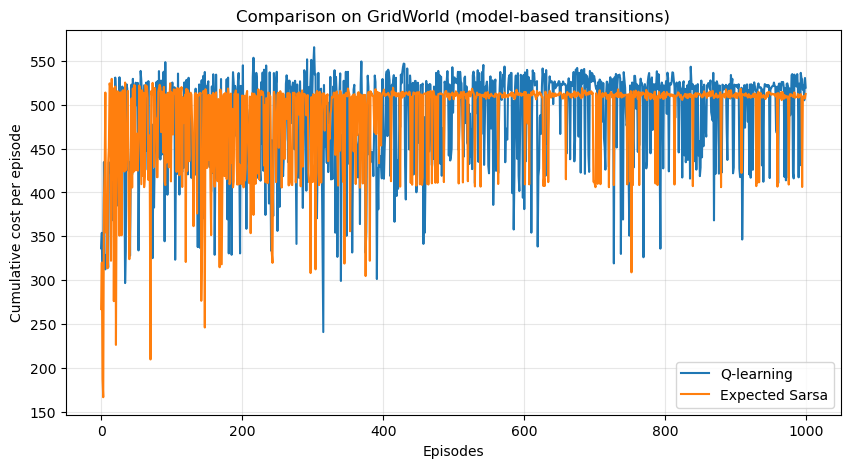

In [22]:
print("Running Q‑Learning...")
ql_costs = run_experiment(QLearningAgent, env, num_runs=5, num_episodes=1000, max_steps=500)

print("Running Expected Sarsa...")
es_costs = run_experiment(ExpectedSarsaAgent, env, num_runs=5, num_episodes=1000, max_steps=500)

plt.figure(figsize=(10,5))
plt.plot(np.mean(ql_costs, axis=0), label="Q-learning")
plt.plot(np.mean(es_costs, axis=0), label="Expected Sarsa")
plt.xlabel("Episodes")
plt.ylabel("Cumulative cost per episode")
plt.title("Comparison on GridWorld (model-based transitions)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 9: State‑Visit Heatmaps

Generating heatmaps...


Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [00:16<00:00,  5.39s/it]


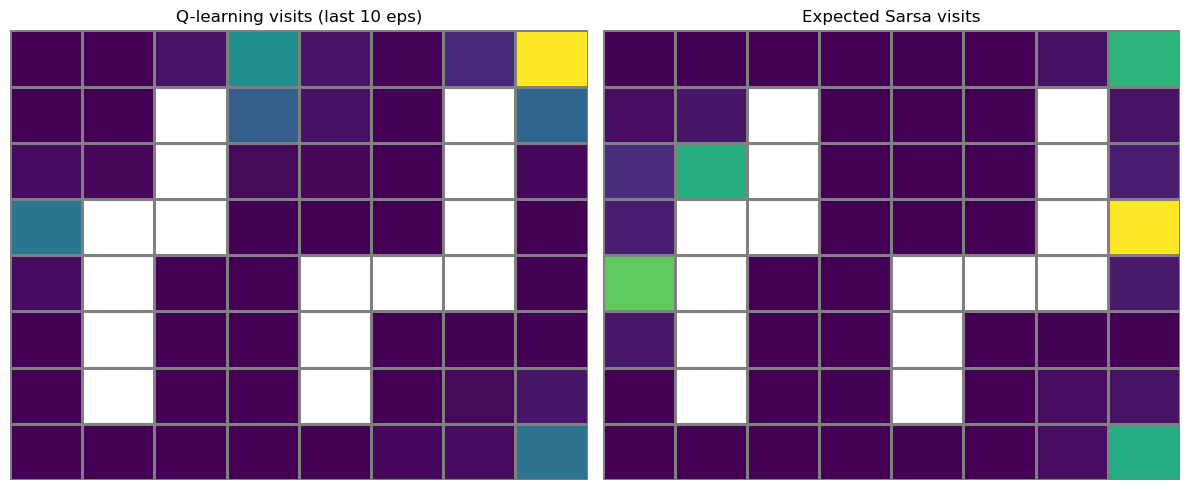

In [23]:
def run_with_visits(agent_class, env, num_runs=5, num_episodes=1000,
                    epsilon=0.1, step_size=0.5, discount=1.0):
    all_visits = []
    for run in tqdm(range(num_runs), desc="Runs"):
        agent = agent_class(NUM_STATES, NUM_ACTIONS, epsilon, step_size, discount, seed=run)
        visits = np.zeros(NUM_STATES)
        for ep in range(num_episodes):
            state = env.reset()
            action = agent.start_episode(state)
            if ep >= num_episodes - 10:
                visits[state] += 1
            done = False
            steps = 0
            while not done and steps < 500:
                next_state, cost, done, _ = env.step(action)
                if ep >= num_episodes - 10:
                    visits[next_state] += 1
                action = agent.step(cost, next_state, done)
                steps += 1
        all_visits.append(visits)
    return np.mean(all_visits, axis=0)

print("Generating heatmaps...")
ql_visits = run_with_visits(QLearningAgent, env, num_runs=3, num_episodes=100)
es_visits = run_with_visits(ExpectedSarsaAgent, env, num_runs=3, num_episodes=100)

# Reshape to 8x8 and mask blocked/terminal
grid_ql = ql_visits.reshape(8,8)
grid_es = es_visits.reshape(8,8)
for idx in inv_st:
    r, c = idx // 8, idx % 8
    grid_ql[r, c] = np.nan
    grid_es[r, c] = np.nan
# Terminal state (36) may also be visited; keep as is.

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.pcolormesh(grid_ql, edgecolors='gray', linewidth=1, cmap='viridis')
plt.title("Q-learning visits (last 10 eps)")
plt.axis('off')
plt.subplot(1,2,2)
plt.pcolormesh(grid_es, edgecolors='gray', linewidth=1, cmap='viridis')
plt.title("Expected Sarsa visits")
plt.axis('off')
plt.tight_layout()
plt.show()

#### 10:Step‑Size Sensitivity

Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [01:20<00:00, 26.90s/it]

Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [01:33<00:00, 31.09s/it]

Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [01:34<00:00, 31.45s/it]

Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [01:33<00:00, 31.08s/it]

Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [01:33<00:00, 31.15s/it]

Step-sizes: 100%|███████████████████████████████████████████████████████████████████████| 5/5 [19:55<00:00, 239.07s/it]


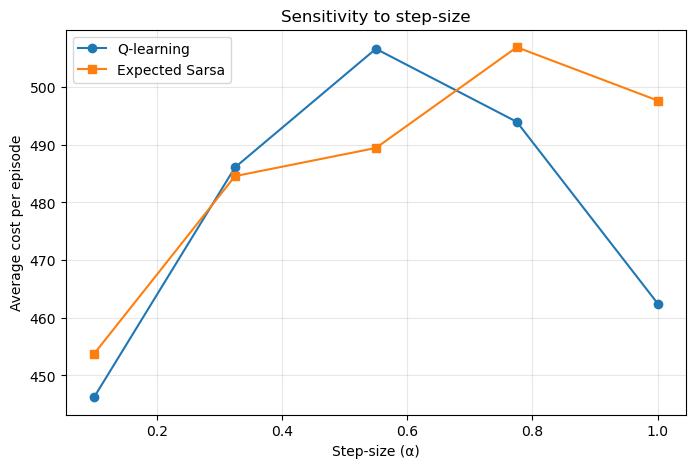

In [24]:
step_sizes = np.linspace(0.1, 1.0, 5)
num_runs_ss = 3
num_episodes_ss = 1000

results = {"Q-learning": [], "Expected Sarsa": []}
for ss in tqdm(step_sizes, desc="Step-sizes"):
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_ss,
                        num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_ss,
                        num_episodes=num_episodes_ss, step_size=ss, max_steps=500)
    results["Q-learning"].append(np.mean(ql))
    results["Expected Sarsa"].append(np.mean(es))

plt.figure(figsize=(8,5))
plt.plot(step_sizes, results["Q-learning"], 'o-', label="Q-learning")
plt.plot(step_sizes, results["Expected Sarsa"], 's-', label="Expected Sarsa")
plt.xlabel("Step-size (α)")
plt.ylabel("Average cost per episode")
plt.title("Sensitivity to step-size")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 11: Discount Factor < 1


Discount γ = 1.0


Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [02:33<00:00, 51.14s/it]


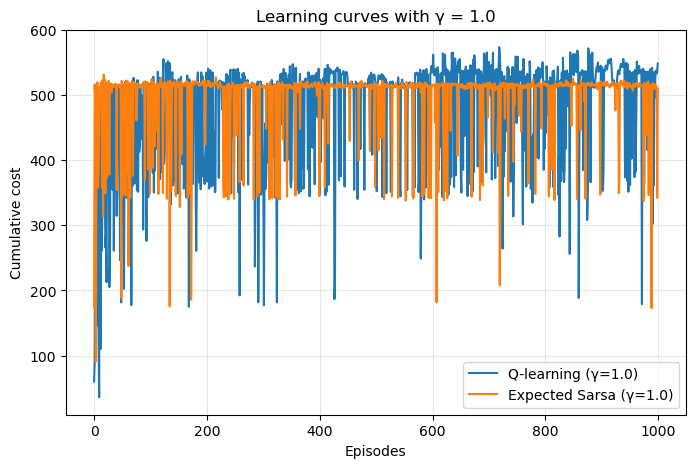


Discount γ = 0.95


Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [02:19<00:00, 46.50s/it]


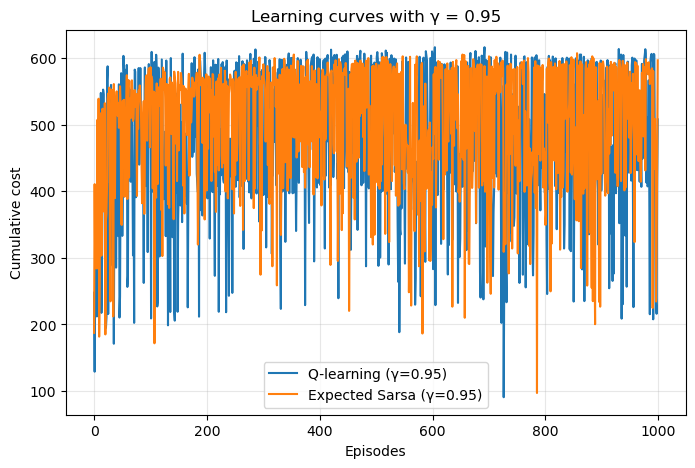


Discount γ = 0.9


Runs: 100%|██████████████████████████████████████████████████████████████████████████████| 3/3 [02:12<00:00, 44.19s/it]


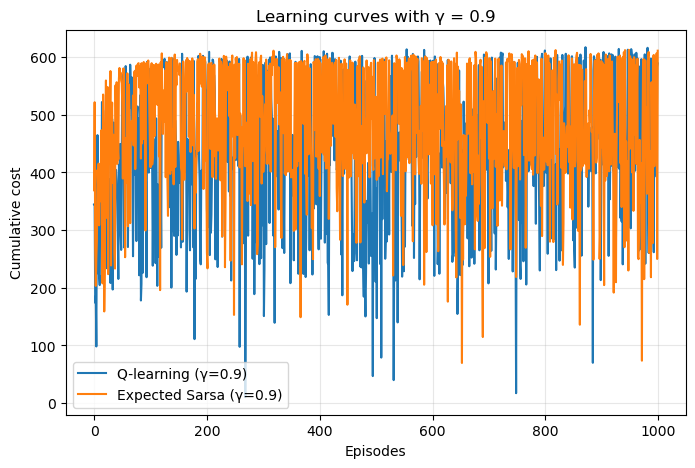

In [25]:
discounts = [1.0, 0.95, 0.9]
num_runs_disc = 3
num_episodes_disc = 1000

for gamma in discounts:
    print(f"\nDiscount γ = {gamma}")
    ql = run_experiment(QLearningAgent, env, num_runs=num_runs_disc,
                        num_episodes=num_episodes_disc, discount=gamma, max_steps=500)
    es = run_experiment(ExpectedSarsaAgent, env, num_runs=num_runs_disc,
                        num_episodes=num_episodes_disc, discount=gamma, max_steps=500)
    plt.figure(figsize=(8,5))
    plt.plot(np.mean(ql, axis=0), label=f"Q-learning (γ={gamma})")
    plt.plot(np.mean(es, axis=0), label=f"Expected Sarsa (γ={gamma})")
    plt.xlabel("Episodes")
    plt.ylabel("Cumulative cost")
    plt.title(f"Learning curves with γ = {gamma}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## Results Discussion

The precomputed transition model makes the environment deterministic in terms of probabilities, but still stochastic when sampled. This leads to faster execution because we avoid the per‑step loops of the original environment.

- **Q‑learning** tends to find the optimal path but may occasionally fall into high‑cost states due to exploration.
- **Expected Sarsa** accounts for the ε‑greedy policy during updates, resulting in a safer policy and often lower cumulative cost, especially early in training.
- The step‑size sensitivity shows that Expected Sarsa is more robust to large α.
- A discount factor less than 1 (e.g., γ = 0.9) can speed up convergence by reducing the weight of distant costs, but may also lead to suboptimal policies in this undiscounted episodic task.

These results align with the theoretical differences between the two algorithms and replicate the findings of the original Cliff World experiment.